# Southwest US: Monthly Low-Cloud Sentinel-2 Array

This notebook demonstrates how to use `lazycogs` to lazily load a lowest-cloud monthly composite array of Sentinel-2 Level 2A data over the US Southwest. Items are filtered to <50% cloud cover and sorted by cloud cover so that the array is generated from the least-cloudy scenes. The array covers spring 2025 (March–June) at 300 m resolution in EPSG:3310.

In [1]:
from pathlib import Path

import rustac
from pyproj import Transformer

import lazycogs

Define the area of interest with a CRS and a bounding box, then query the STAC API.

In [2]:
# define the AOI in a projection that is suitable for your analysis
dst_crs = "epsg:3310"
dst_bbox = (-444000, -609000, 681000, 500000)

# transform to epsg:4326 for STAC search
transformer = Transformer.from_crs(dst_crs, "epsg:4326", always_xy=True)
bbox_4326 = transformer.transform_bounds(*dst_bbox)

PARQUET = "data/ca_spring_2025.parquet"

if not Path(PARQUET).exists():
    Path(PARQUET).parent.mkdir(exist_ok=True)
    await rustac.search_to(
        PARQUET,
        href="https://earth-search.aws.element84.com/v1",
        collections=["sentinel-2-c1-l2a"],
        datetime="2025-03-01/2025-06-30",
        bbox=bbox_4326,
        limit=100,
    )

print(f"Using {PARQUET}")

Using data/ca_spring_2025.parquet


Open an array with 300 meter resolution with records flattened by month, only processing records with <50% cloud cover. This will result in an array with one time coordinate per month, the least cloudy images will be used first when fetching actual data.

In [3]:
store = lazycogs.store_for(PARQUET, skip_signature=True)

ca_monthly = lazycogs.open(
    PARQUET,
    crs=dst_crs,
    bbox=dst_bbox,
    resolution=300,
    time_period="P1M",
    bands=["red", "green", "blue"],
    dtype="int16",
    filter="eo:cloud_cover < 50",
    sortby="eo:cloud_cover",
    store=store,
)

ca_monthly

<xarray.DataArray (band: 3, time: 4, y: 3697, x: 3750)> Size: 333MB
[166365000 values with dtype=int16]
Coordinates:
  * band         (band) <U5 60B 'red' 'green' 'blue'
  * time         (time) datetime64[s] 32B 2025-03-01 2025-04-01 ... 2025-06-01
  * y            (y) float64 30kB 4.998e+05 4.996e+05 ... -6.086e+05 -6.09e+05
  * x            (x) float64 30kB -4.438e+05 -4.436e+05 ... 6.806e+05 6.808e+05
    spatial_ref  int64 8B 0
Indexes:
  ┌ x        RasterIndex (crs=EPSG:3310)
  └ y
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'name': 'spatial:', 'uuid': '689b58e2-cf7b-45e...
    spatial:transform:       [300.0, 0.0, -444000.0, 0.0, -300.0, 500000.0]
    spatial:transform_type:  affine
    spatial:registration:    pixel
    proj:code:               EPSG:3310
    _stac_backend:           MultiBandStacBackendArray(bands=['red', 'green',...
    _stac_time_coords:       2025-03-01 … 2025-06-01 (n=4)

In [4]:
ca_may = ca_monthly.chunk(x=1024, y=1024).sel(time="2025-05-01")
ca_may

<xarray.DataArray (band: 3, y: 3697, x: 3750)> Size: 83MB
dask.array<getitem, shape=(3, 3697, 3750), dtype=int16, chunksize=(3, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * band         (band) <U5 60B 'red' 'green' 'blue'
  * y            (y) float64 30kB dask.array<chunksize=(1024,), meta=np.ndarray>
  * x            (x) float64 30kB dask.array<chunksize=(1024,), meta=np.ndarray>
    time         datetime64[s] 8B 2025-05-01
    spatial_ref  int64 8B 0
Indexes:
  ┌ x        RasterIndex (crs=EPSG:3310)
  └ y
Attributes:
    grid_mapping:            spatial_ref
    zarr_conventions:        [{'name': 'spatial:', 'uuid': '689b58e2-cf7b-45e...
    spatial:transform:       [300.0, 0.0, -444000.0, 0.0, -300.0, 500000.0]
    spatial:transform_type:  affine
    spatial:registration:    pixel
    proj:code:               EPSG:3310
    _stac_backend:           MultiBandStacBackendArray(bands=['red', 'green',...
    _stac_time_coords:       2025-03-01 … 2025-06-01 (n=4)

Show the query plan summary including overview and window information. This will open the COG headers for all relevant files so it can take a while.

In [5]:
plan = ca_may.lazycogs.explain(fetch_headers=True)

print(plan.summary())

=== ExplainPlan ===
Parquet:    data/ca_spring_2025.parquet
CRS:        epsg:3310  |  Resolution: 300.0 units/px  |  Grid: 3750 x 3697 px
Bands (3):  red, green, blue
Time steps: 1 (2025-05-01)
Chunks:     1024 x 1024 px -> 4x4 spatial tiles

Total chunk reads:     48 (3 band(s) x 1 time step(s) x 16 spatial tile(s))
Total COG reads:       8862
Chunks with 0 COGs:       0 (0.0%)
Chunks with 1 COG:        0 (0.0%)
Chunks with 2+ COGs:     48 (100.0%)
Max COGs per chunk:    333
Overview levels:       ovr 3: 8862
Avg read window:       520 x 479 px
(Use .to_dataframe() for per-item overview and window details.)


Load the array.

In [ ]:
_ = await ca_may.load_async()

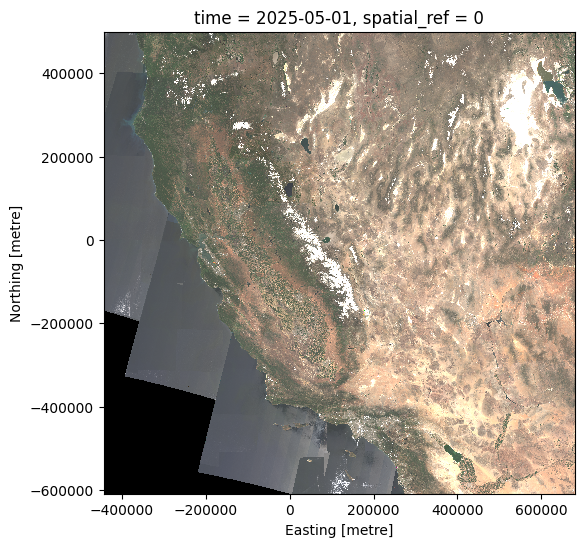

In [8]:
ca_may.plot.imshow(
    rgb="band",
    vmin=0,
    vmax=4000,
    size=6,
    aspect=ca_may.shape[2] / ca_may.shape[1],
)